<a href="https://colab.research.google.com/github/hyrinn/Machine_Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

## Import modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Load datasets

In [ ]:
# Load dataset file
data = pd.read_csv('KC House Data.csv', usecols=['price', 'sqft_living'])
data

,price,sqft_living
0,221900.0,1180
1,538000.0,2570
2,180000.0,770
3,604000.0,1960
4,510000.0,1680
...,...,...
21608,360000.0,1530
21609,400000.0,2310
21610,402101.0,1020
21611,400000.0,1600


(17290, 1)
(17290, 1)


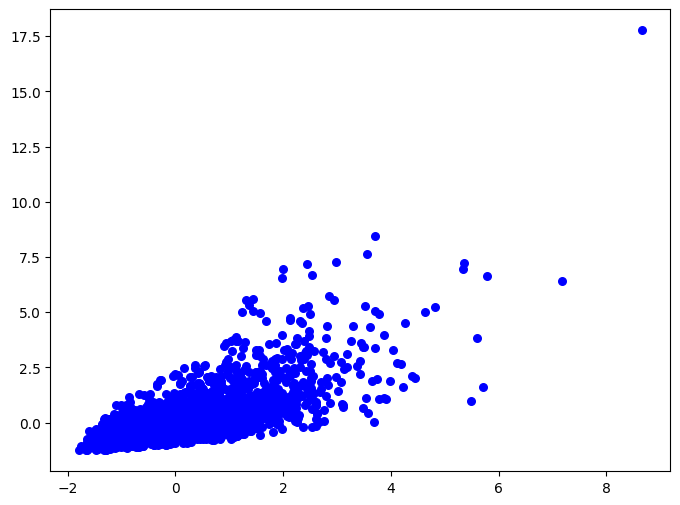

In [ ]:
# Numpy 배열로 전환
data_np = np.array(data)

x = data_np[:, 1]          # sqft_living
y = data_np[:, 0]          # price

# Dataset 정규화
x_mean = np.mean(x)
y_mean = np.mean(y)
x_std = np.std(x)
y_std = np.std(y)

x = (x-x_mean)/x_std
y = (y-y_mean)/y_std

# 2차원 행렬 변환
x = np.expand_dims(x, 1)
y = np.expand_dims(y, 1)

# Train dataset / Test dataset 분할
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1234)

print(x_train.shape)
print(y_train.shape)

# 시각화
fig = plt.figure(figsize=(8,6))
plt.scatter(x_test, y_test, color='b', marker='o', s=30)
plt.show()

## Least Square Method

- a 행렬과 똑같은 크기의 1로 채워진 행렬 생성:
  ```python
  arr = np.ones_like(a)
  ```
- 행렬 가로 쌓기:
  ```ptrhon
  arr = np.hstack([a, b])
  ```
- 행렬 곱:
  ```python
  arr = np.dot(a, b)
  ```
- 전치 행렬:
  ```python
  arr = a.T
  ```
- 역 행렬:
  ```python
  arr = np.linalg.inv(a)
  ```


- Goal:
$$\theta = (X^T \cdot X)^{-1} \cdot (X^T \cdot Y)$$


In [ ]:
def LSM(x, y):
  bias = np.ones_like(x)
  X = np.hstack([x, bias])

  XT = X.T

  XTX = np.dot(XT, X)
  XTX_inverse = np.linalg.inv(XTX)

  XTY = np.dot(XT, y)

  theta = np.dot(XTX_inverse, XTY)

  w = theta[0]
  b = theta[1]
  return w, b

In [ ]:
w, b = LSM(x_train, y_train)
print(w, b)

[0.70406843] [0.00267388]


## Prediction

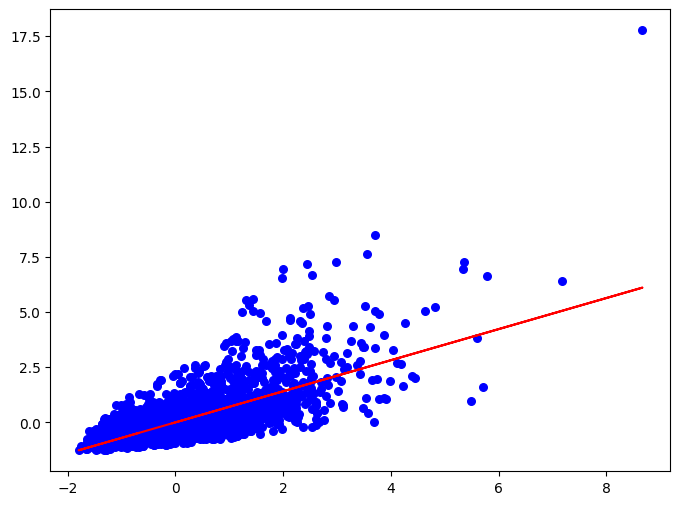

In [ ]:
# Test dataset을 이용한 예측
y_ = []
for i in x_test:
  y_.append(i*w + b)

# 시각화
fig = plt.figure(figsize=(8,6))
plt.scatter(x_test, y_test, color='b', marker='o', s=30)
plt.plot(x_test, y_, color='r')
plt.show()

## Gradient Decent Method

In [ ]:
def GDM(x, y):
  # 하이퍼 파라미터 설정
  learning_rate = 0.1
  n_iters = 100

  # w, b 초기값 설정
  w = 0
  b = 0

  # 행렬 X에 bias 열 추가
  bias = np.ones_like(x)
  X = np.hstack([x, bias])
  N = x.shape[0] #데이터 포인트의 개수를 계산하기 위해

  for i in range(n_iters):
    # [[w],
    #  [b]] 행렬 생성
    theta = np.array([w, b])
    theta = theta.reshape(2, 1)

    # y_hat 계산
    y_hat = np.dot(X, theta)

    # dw, db 계산
    # dw = 1/N * sum(y - y_hat) * -X (* bias 열 없는 X)
    # db = 1/N * sum(y - y_hat) * -1
    dw = (1/N) * np.sum((y - y_hat) * (-x))
    db = (1/N) * np.sum((y - y_hat) * (-1))

    # w, b 업데이트
    # w_t+1 = w_t - learning rate * dw
    # b_t+1 = b_t - learning rate * db
    w = theta[0] - learning_rate * dw
    b = theta[1] - learning_rate * db

    print(f'w:{w}\tb: {b}')

  return w, b

In [ ]:
w, b = GDM(x_train, y_train)
print(w, b)

w:[0.07050266]	b: [-0.00014548]
w:[0.13394522]	b: [-0.00023507]
w:[0.19103469]	b: [-0.0002785]
w:[0.24240729]	b: [-0.00028411]
w:[0.28863553]	b: [-0.00025903]
w:[0.33023456]	b: [-0.00020936]
w:[0.36766796]	b: [-0.00014025]
w:[0.40135289]	b: [-5.61052385e-05]
w:[0.43166471]	b: [3.93787435e-05]
w:[0.45894122]	b: [0.00014309]
w:[0.48348636]	b: [0.00025242]
w:[0.50557366]	b: [0.00036522]
w:[0.52544924]	b: [0.00047969]
w:[0.54333458]	b: [0.00059436]
w:[0.55942897]	b: [0.00070806]
w:[0.57391177]	b: [0.00081982]
w:[0.58694435]	b: [0.0009289]
w:[0.59867194]	b: [0.00103472]
w:[0.6092252]	b: [0.00113683]
w:[0.61872174]	b: [0.00123492]
w:[0.62726737]	b: [0.00132877]
w:[0.63495731]	b: [0.00141824]
w:[0.64187725]	b: [0.00150328]
w:[0.64810428]	b: [0.00158387]
w:[0.6537078]	b: [0.00166005]
w:[0.65875023]	b: [0.0017319]
w:[0.66328777]	b: [0.00179953]
w:[0.66737096]	b: [0.00186305]
w:[0.67104531]	b: [0.00192261]
w:[0.67435175]	b: [0.00197837]
w:[0.67732712]	b: [0.0020305]
w:[0.68000457]	b: [0.00207916

## Prediction

w:[0.07050266]	b: [-0.00014548]
w:[0.13394522]	b: [-0.00023507]
w:[0.19103469]	b: [-0.0002785]
w:[0.24240729]	b: [-0.00028411]
w:[0.28863553]	b: [-0.00025903]
w:[0.33023456]	b: [-0.00020936]
w:[0.36766796]	b: [-0.00014025]
w:[0.40135289]	b: [-5.61052385e-05]
w:[0.43166471]	b: [3.93787435e-05]
w:[0.45894122]	b: [0.00014309]
w:[0.48348636]	b: [0.00025242]
w:[0.50557366]	b: [0.00036522]
w:[0.52544924]	b: [0.00047969]
w:[0.54333458]	b: [0.00059436]
w:[0.55942897]	b: [0.00070806]
w:[0.57391177]	b: [0.00081982]
w:[0.58694435]	b: [0.0009289]
w:[0.59867194]	b: [0.00103472]
w:[0.6092252]	b: [0.00113683]
w:[0.61872174]	b: [0.00123492]
w:[0.62726737]	b: [0.00132877]
w:[0.63495731]	b: [0.00141824]
w:[0.64187725]	b: [0.00150328]
w:[0.64810428]	b: [0.00158387]
w:[0.6537078]	b: [0.00166005]
w:[0.65875023]	b: [0.0017319]
w:[0.66328777]	b: [0.00179953]
w:[0.66737096]	b: [0.00186305]
w:[0.67104531]	b: [0.00192261]
w:[0.67435175]	b: [0.00197837]
w:[0.67732712]	b: [0.0020305]
w:[0.68000457]	b: [0.00207916

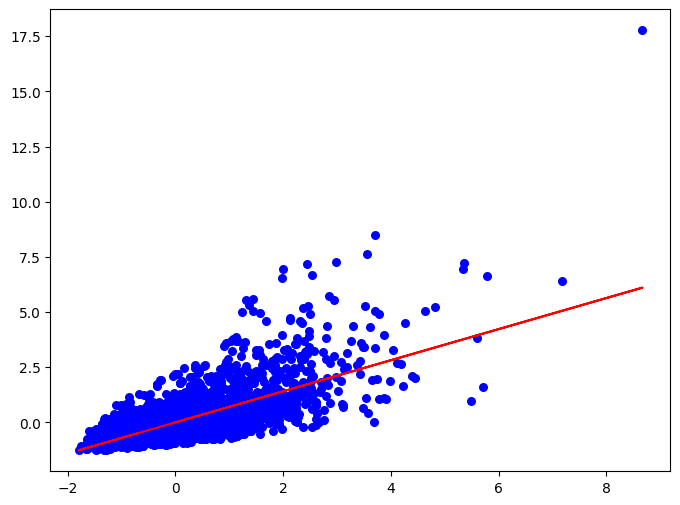

In [ ]:
# Test dataset을 이용한 예측
y_ = []
for i in x_test:
  y_.append(i*w + b)

# 시각화
fig = plt.figure(figsize=(8,6))
plt.scatter(x_test, y_test, color='b', marker='o', s=30)
plt.plot(x_test, y_, color='r')
plt.show()